In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import numpy as np
from scipy.stats import mannwhitneyu

from matplotlib.transforms import blended_transform_factory
import matplotlib.patches as mpatches
from statsmodels.stats.multitest import multipletests

from matplotlib.patches import FancyArrowPatch

In [2]:
# Read in the clustering data which Michael sent me
files = pd.read_csv('../data/Radius_100_patient_id_edited.csv')

In [3]:
# Add clinical information to the dataframe
outcomes = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx')
outcomes['Outcome_C6_revised_Vid'] = outcomes['Outcome_C6_revised_Vid'].replace('non-responder_2', 'Non-responder').replace('responder_1', 'Responder')
outcomes['Outcome_C12_CC486'] = outcomes['Outcome_C12_CC486'].replace('non-responder_2', 'Non-responder').replace('responder_1', 'Responder')

outcomes_6 = dict(zip(outcomes['PID'], outcomes['Outcome_C6_revised_Vid']))
outcomes_12 = dict(zip(outcomes['PID'], outcomes['Outcome_C12_CC486']))
diagnosis = dict(zip(outcomes['PID'], outcomes['Diagnosis']))

files['diagnosis'] = files['PID'].map(diagnosis)
files['outcomes_6'] = files['PID'].map(outcomes_6)
files['outcomes_12'] = files['PID'].map(outcomes_12)

In [4]:
for i in files['pid_tp'].unique():
    if 'P18' in i:
        print(i)

P18_C1
P18_C7
P18_Prog


In [5]:
# Delete the patient P02 as it has few cells. This patient 
files = files.loc[files['PID'] != 'P02', :]
print(len(files['pid_tp'].unique()))
files = files.loc[~((files['PID'] == 'P04') & (files['tp'] == 'C12')), :] # exclude this patient as Jake didn't include it in his statistical analysis
#files = files.loc[~((files['PID'] == 'P18') & (files['tp'] == 'Prog')), :] # Jake included this timepoint in his analysis
files = files.loc[~((files['PID'] == 'P03') & (files['tp'] == 'C12')), :]
print(len(files['pid_tp'].unique()))

32
30


In [6]:
for i in files['pid_tp'].unique():
    if 'P18' in i:
        print(i)

P18_C1
P18_C7
P18_Prog


In [7]:
# Create a dictionary of patients with a C1 and a C12 observation
patient_c12_dict = {}
for i in files['pid_tp'].unique():
    if i.endswith('C1'):
        b = files.loc[files['PID'] == i.split('_')[0], :]
        # if 'C7' in b['tp'].unique():
        #     print(i, outcomes_[i.split('_')[0]])
        if 'C12' in b['tp'].unique():
            print(i, outcomes_12[i.split('_')[0]])
            patient_c12_dict[i] = outcomes_12[i.split('_')[0]]
patient_c12_dict

P05_C1 Non-responder
P01_C1 Responder
P11_C1 Responder
P07_C1 Responder


{'P05_C1': 'Non-responder',
 'P01_C1': 'Responder',
 'P11_C1': 'Responder',
 'P07_C1': 'Responder'}

In [8]:
# Create a dictionary 

response_dict = {}
for i in files['pid_tp'].unique():
    if 'C12' in i:
        response_dict[i] = outcomes_12[i.split('_')[0]]
    elif 'C7' in i:
        response_dict[i] = outcomes_6[i.split('_')[0]]
    elif 'Prog' in i:
        response_dict[i] = 'Non-responder'
    elif i in patient_c12_dict.keys():
        response_dict[i] = patient_c12_dict[i]
    elif 'C1' in i:
        response_dict[i] = outcomes_6[i.split('_')[0]]
response_dict

{'P08_C1': 'Non-responder',
 'P08_C7': 'Non-responder',
 'P24_C1': 'Non-responder',
 'P19_C1': 'Responder',
 'P12_C12': 'Responder',
 'P04_C1': 'Responder',
 'P04_C7': 'Responder',
 'P03_C1': 'Responder',
 'P03_C7': 'Responder',
 'P16_C1': 'Non-responder',
 'P14_C1': 'Responder',
 'P14_Prog': 'Non-responder',
 'P05_C1': 'Non-responder',
 'P05_C12': 'Non-responder',
 'P01_C1': 'Responder',
 'P01_C12': 'Responder',
 'P11_C1': 'Responder',
 'P11_C12': 'Responder',
 'P28_C1': 'Non-responder',
 'P07_C1': 'Responder',
 'P07_C12': 'Responder',
 'P17_C1': 'Responder',
 'P18_C1': 'Responder',
 'P18_C7': 'Responder',
 'P18_Prog': 'Non-responder',
 'P22_C1': 'Non-responder',
 'P25_C1': 'Non-responder',
 'P25_C7': 'Non-responder',
 'P13_C1': 'Responder',
 'P21_C1': 'Responder'}

In [9]:
response_dict

{'P08_C1': 'Non-responder',
 'P08_C7': 'Non-responder',
 'P24_C1': 'Non-responder',
 'P19_C1': 'Responder',
 'P12_C12': 'Responder',
 'P04_C1': 'Responder',
 'P04_C7': 'Responder',
 'P03_C1': 'Responder',
 'P03_C7': 'Responder',
 'P16_C1': 'Non-responder',
 'P14_C1': 'Responder',
 'P14_Prog': 'Non-responder',
 'P05_C1': 'Non-responder',
 'P05_C12': 'Non-responder',
 'P01_C1': 'Responder',
 'P01_C12': 'Responder',
 'P11_C1': 'Responder',
 'P11_C12': 'Responder',
 'P28_C1': 'Non-responder',
 'P07_C1': 'Responder',
 'P07_C12': 'Responder',
 'P17_C1': 'Responder',
 'P18_C1': 'Responder',
 'P18_C7': 'Responder',
 'P18_Prog': 'Non-responder',
 'P22_C1': 'Non-responder',
 'P25_C1': 'Non-responder',
 'P25_C7': 'Non-responder',
 'P13_C1': 'Responder',
 'P21_C1': 'Responder'}

In [10]:
# Create a dictionary which details the percentage of cells in each cluster for each patient
df_dict = {}
for i in files['PID'].unique():
    a = files.loc[files['PID'] == i, :]
    df_dict[i] = {}  #
    for e in a['tp'].unique():
        data = a.loc[a['tp'] == e, :]
        df_dict[i][e] = data['Leiden_Group'].value_counts(normalize = True) * 100
df_dict

{'P08': {'C1': Leiden_Group
  11    11.283780
  2      8.361433
  10     7.872746
  8      6.299174
  5      5.419538
  6      5.116552
  4      4.588770
  34     4.202707
  19     3.718907
  32     3.152030
  9      3.093388
  13     3.044519
  30     2.893026
  16     2.428774
  29     2.252847
  40     2.228412
  38     2.150222
  22     2.116014
  21     2.116014
  25     1.910766
  20     1.910766
  31     1.583346
  0      1.558911
  28     1.480721
  18     1.299907
  42     0.884523
  17     0.806333
  27     0.762352
  14     0.723257
  39     0.664614
  37     0.654840
  26     0.576651
  15     0.557103
  33     0.508234
  1      0.474026
  7      0.327420
  23     0.317646
  12     0.307873
  35     0.131945
  24     0.068416
  44     0.043982
  3      0.039095
  54     0.014661
  45     0.014661
  49     0.009774
  36     0.009774
  52     0.009774
  53     0.004887
  47     0.004887
  Name: proportion, dtype: float64,
  'C7': Leiden_Group
  8     14.464935
  4      9.1832

In [11]:
# Turn my dictionaries into a dataframe. df_dict is a multilevel index
df = pd.DataFrame({(alias, tp): counts 
                   for alias, tp_dict1 in df_dict.items() 
                   for tp, counts in tp_dict1.items()})
df.columns = pd.MultiIndex.from_tuples(df.columns, names=['alias', 'tp'])
df.columns = ['_'.join(map(str, col)) for col in df.columns]
df = df.fillna(0).T
df.head()

Leiden_Group,0,1,2,3,4,5,6,7,8,9,...,49,50,51,52,53,54,55,56,57,58
P08_C1,1.558911,0.474026,8.361433,0.039095,4.588770,5.419538,5.116552,0.327420,6.299174,3.093388,...,0.009774,0.0,0.0,0.009774,0.004887,0.014661,0.000000,0.000000,0.000000,0.000000
P08_C7,0.219546,0.131728,4.278008,0.000000,9.183289,1.875549,0.796638,0.514365,14.464935,7.282650,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P24_C1,5.580866,0.004218,1.434236,0.000000,1.501730,1.387834,0.890070,0.105459,0.168734,1.143171,...,0.004218,0.0,0.0,0.008437,0.033747,0.012655,0.012655,0.033747,0.050620,0.016873
P19_C1,2.362156,0.055508,1.276674,0.000000,4.570125,6.784261,0.585913,1.171827,4.372764,2.534846,...,0.000000,0.0,0.0,0.006168,0.000000,0.000000,0.018503,0.000000,0.000000,0.000000
P12_C12,3.973805,0.171381,1.986903,0.000000,3.773164,1.469974,2.162463,0.124007,6.775812,2.487112,...,0.006967,0.0,0.0,0.000000,0.001393,0.016720,0.001393,0.001393,0.001393,0.000000


In [12]:
# Add clinical information to each df to specify whether an observation is a pre or a post timepoint
df['response'] = df.index.map(response_dict)

timepoint = []
for i in df.index.str.split('_').str[1]:
    if ('C12' in i) | ('C7' in i) | ('Prog' in i):
        timepoint.append('post')
    else:
        timepoint.append('pre')
df['timepoint'] = timepoint

In [13]:
# Read in the p-values which was produced by Jake on 2026_03_06. These are the updated p-values for the non-responder
# samples for diagnosis versus non-response
nr = pd.read_excel('../data/2026_03_06_p_values_from_jake.xlsx')
nr = nr.sort_values('p_value')
nr['Class'] = 'Non-responder'
nr = nr.loc[nr['p_value'] <= 0.1, :]
nr['Cluster']

14    14
15    15
26    26
35    35
21    21
24    24
23    23
7      7
5      5
20    20
34    34
1      1
31    31
6      6
12    12
28    28
29    29
33    33
18    18
9      9
17    17
22    22
39    39
19    19
4      4
43    43
3      3
41    41
13    13
0      0
Name: Cluster, dtype: int64

In [14]:
# Read in the p-value which Jake sent me on the 14th of February
p_val = pd.read_excel('../data/2026_02_14_p_values_from_jake.xlsx', sheet_name= 'Responders_diagnosis_v_response')
p_val['class'] = 'Responder'
pvals = p_val['p_value'].to_list()  # your list

p_val = p_val.sort_values('p_value', ascending = True)
p_val.head(10)

,Cluster,p_value,Estimate,class
30,30,0.0001,Neg,Responder
8,8,0.0001,Neg,Responder
38,38,0.0002,Neg,Responder
28,28,0.0182,Pos,Responder
16,16,0.0201,Pos,Responder
43,43,0.0208,Neg,Responder
19,19,0.0219,Pos,Responder
12,12,0.0224,Neg,Responder
15,15,0.0384,Pos,Responder
42,42,0.0448,Neg,Responder


In [15]:
import numpy as np
from matplotlib.patches import Polygon

def add_significance_stars(ax, x, y, p_value, is_responder, cluster, outcome_params, line_y, fontsize=8):
    thresholds = [(0.0001, '****'), (0.001, '***'), (0.01, '**'), (0.05, '*')]
    stars = next((s for threshold, s in thresholds if p_value < threshold), None)
    if not stars:
        return
    bar_width = 0.35
    group_key = 'Responder' if is_responder else 'Non-responder'
    multiplier = 1 if is_responder else -1
    y_limit = ax.get_ylim()[1]
    star_y = line_y + (y_limit * 0.15 * multiplier)
    # Look up Estimate
    estimate = outcome_params[group_key]['df']
    estimate = estimate.loc[estimate['Cluster'] == cluster, 'Estimate']
    estimate = estimate.values[0] if not estimate.empty else 'Pos'
    
    # Horizontal line
    line_xmin = x - bar_width/2 - 0.025
    line_xmax = x + bar_width/2 + 0.025
    ax.hlines(y=line_y, xmin=line_xmin, xmax=line_xmax,
              colors='black', linewidth=0.8, clip_on=False)
    arrow_dx = bar_width * 0.5
    arrow_dy = y_limit * 0.15 * multiplier * (1 if estimate == 'Neg' else -1)
    line_center = x

    ax.text(x, star_y, stars, ha='center', va='center', fontsize=fontsize)

In [16]:
# Read in cell type colors 
colors = pd.read_excel('../data/cell_type_colors.xlsx', sheet_name='2026_02_23')
colors.loc[len(colors)] = ['Endo', '#FFD94AFF']
colors_dict = dict(zip(colors['Cell_Type'], colors['Color']))
colors_dict

# Read in cluster dataframe which details the focal cell identity of any cluster
cluster = pd.read_excel('../data/2026_02_27_cluster_to_cell_type.xlsx')

# Create a dictionary which maps the clusters to a color
cluster_dict = {}
for x, y in zip(cluster['Cluster'], cluster['Cell_type']):
    cluster_dict[x] = colors_dict[y]

In [17]:
# Order the categories list to allow for easy plotting

# Create a list of clusters to plot
categories = [12, 42, 20, 8, 30, 38, 7, 14, 15, 21, 23, 24, 26, 35, 5]

order = ['CD8_T','CD4_T', 
         'Stromal','HSPC',
 'Endothelial',
 'Endo', 'Mixed']

cluster_dict1 = dict(zip(cluster['Cluster'], cluster['Cell_type']))
cluster_dict1

list_ordered = []
for i in order:
    for x, y in cluster_dict1.items():
        if (y == i) and (x in categories):
            list_ordered.append(x)
            print(x, i)

12 CD8_T
42 CD8_T
20 CD4_T
8 Stromal
30 Stromal
38 Stromal
7 HSPC
14 HSPC
15 HSPC
21 HSPC
23 HSPC
24 HSPC
26 HSPC
35 HSPC
5 Mixed


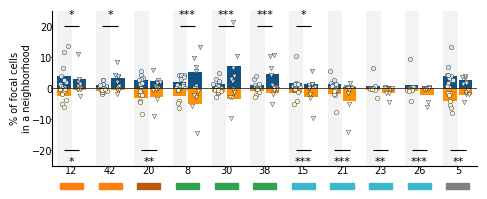

In [18]:
# Plot a bar chart showing the changes in cell types from diagnosis to non-response

fig, ax = plt.subplots(figsize=(4.7, 1.8))

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['pdf.fonttype'] = 'truetype'

colors = {'Non-responder': '#fe9003', 'Responder': '#115284'}
dot_colors = {'Non-responder': '#FFF3CD', 'Responder': '#D0E8F5'}
markers = {'pre': 'o', 'post': 'v'}

categories = [12, 42, 20, 8, 30, 38, 21, 23, 26, 5]
categories = [12, 42, 20, 8, 30, 38,  15, 21, 23, 26, 5]
x_positions = np.arange(len(categories))
bar_width = 0.35

ax.set_ylim(-25, 25)

for outcome in ['Responder', 'Non-responder']:
    multiplier = 1 if outcome == 'Responder' else -1

    for time in ['pre', 'post']:
        offset = -bar_width/2 - 0.025 if time == 'pre' else bar_width/2 + 0.025

        # Raw means from df instead of model estimates
        subset = df[(df['response'] == outcome) & (df['timepoint'] == time)]
        values = subset[categories].mean()  # Series indexed by category

        if time == 'pre':
            hatch_height = 25 * multiplier
            ax.bar(x_positions + offset, hatch_height, bar_width,
                   facecolor='lightgrey',
                   edgecolor='lightgrey',
                   alpha=0.25,
                   linewidth=0.5,
                   zorder=1)
        
        
        ax.bar(x_positions + offset, values.loc[categories].values * multiplier, bar_width,
               color=colors[outcome],
               facecolor=colors[outcome],
               edgecolor=None,
               alpha=1,
               label=f'{outcome} - {time}')

        # Individual data points with jitter
        for category in categories:
            category_data = subset[category]
            x_jitter = np.random.normal(0, 0.05, size=len(category_data))
            ax.scatter(x_positions[categories.index(category)] + offset + x_jitter,
                       category_data * multiplier,
                       marker=markers[time],
                       facecolor=dot_colors[outcome],
                       edgecolor='black', linewidth=0.25,
                       alpha=1, s=10)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

ax.set_xticks(x_positions)
ax.set_xticklabels(labels=categories)
ax.set_xlim(-0.5, len(categories) - 0.5)
ax.tick_params(axis='both', labelsize=7, pad=-1, length=1)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('% of focal cells' + '\n' + 'in a neighborhood', fontsize=7, labelpad=0.1)

outcome_params = {
    'Responder':     {'df': p_val, 'y_tri': 20,  'y_star': 1,   'is_responder': True},
    'Non-responder': {'df': nr,    'y_tri': -20, 'y_star': 0.2, 'is_responder': False},
}

for outcome, params in outcome_params.items():
    df_out = params['df']
    y_limit = ax.get_ylim()[1]
    multiplier = 1 if params['is_responder'] else -1
    line_y = y_limit * 0.80 * multiplier

    for i, category in enumerate(categories):
        if (df_out['Cluster'] == category).any():
            row = df_out.loc[df_out['Cluster'] == category]
            p_value = row['p_value'].values[0]
            add_significance_stars(ax, x_positions[i], params['y_star'], p_value,
                                   is_responder=params['is_responder'],
                                   cluster=category,
                                   outcome_params=outcome_params,
                                   line_y=line_y)

transform = blended_transform_factory(ax.transData, ax.transAxes)
box_width = 0.6
box_height = 0.04
box_y = -0.15

for i, category in enumerate(categories):
    color = cluster_dict.get(category)
    if color:
        rect = mpatches.FancyBboxPatch(
            (x_positions[i] - box_width / 2, box_y),
            box_width, box_height,
            boxstyle="square,pad=0",
            transform=transform,
            color=color,
            clip_on=False
        )
        ax.add_patch(rect)

fig.set_size_inches(4.7, 1.8)
fig.tight_layout(pad=0.1)
# fig.savefig('../results/pre_v_pos_graphs_clinical_observation.pdf',
#             bbox_inches='tight', pad_inches=0.01, dpi=600)